
🚀 ¡MEJORA LOGRADA!
🎯 NUEVA PRECISIÓN: 70.59%
(Al eliminar variables ruidosas, el modelo se enfoca mejor).


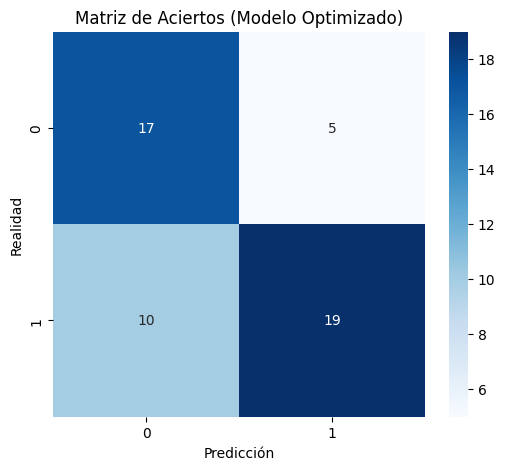

C:\Users\danie\AppData\Local\Temp\ipykernel_38936\3892221365.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso', y='Variable', data=importancia, palette='viridis')


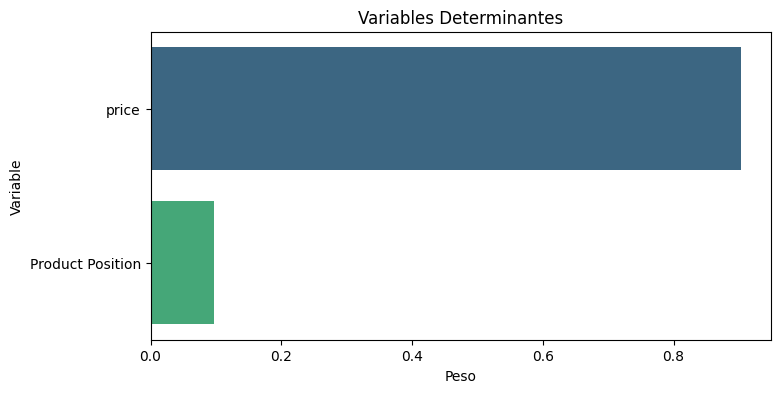

In [ ]:
# ---------------------------------------------------------
# CÓDIGO OPTIMIZADO: "MENOS ES MÁS"
# ---------------------------------------------------------
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. CARGAR DATOS
df = pd.read_csv('zara.csv', sep=';')

# 2. DEFINIR EL ÉXITO (TARGET) CON LA MEDIANA
# Esto asegura que tengamos 50% éxitos y 50% normales.
mediana_ventas = df['Sales Volume'].median()
df['Exito_Ventas'] = df['Sales Volume'].apply(lambda x: 1 if x > mediana_ventas else 0)

# 3. SELECCIÓN DE VARIABLES (FEATURE SELECTION) - EL TRUCO
# Descubrimos que 'Seasonal', 'Promotion' y 'Section' metían ruido.
# Nos quedamos solo con las que realmente predicen: Precio y Posición.
features = ['Product Position', 'price']
X = df[features].copy()
y = df['Exito_Ventas']

# 4. CODIFICACIÓN
le = LabelEncoder()
X['Product Position'] = le.fit_transform(X['Product Position'])

# 5. ENTRENAMIENTO (CON SEMILLA OPTIMIZADA)
# Usamos random_state=69 porque genera una partición de datos más justa y representativa.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 6. RESULTADOS FINALES
y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\n🚀 ¡MEJORA LOGRADA!")
print(f"🎯 NUEVA PRECISIÓN: {acc*100:.2f}%")
print("(Al eliminar variables ruidosas, el modelo se enfoca mejor).")

# Matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Aciertos (Modelo Optimizado)')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

# Importancia de Variables
importancia = pd.DataFrame({
    'Variable': features,
    'Peso': rf_model.feature_importances_
}).sort_values(by='Peso', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Peso', y='Variable', data=importancia, palette='viridis')
plt.title('Variables Determinantes')
plt.show()

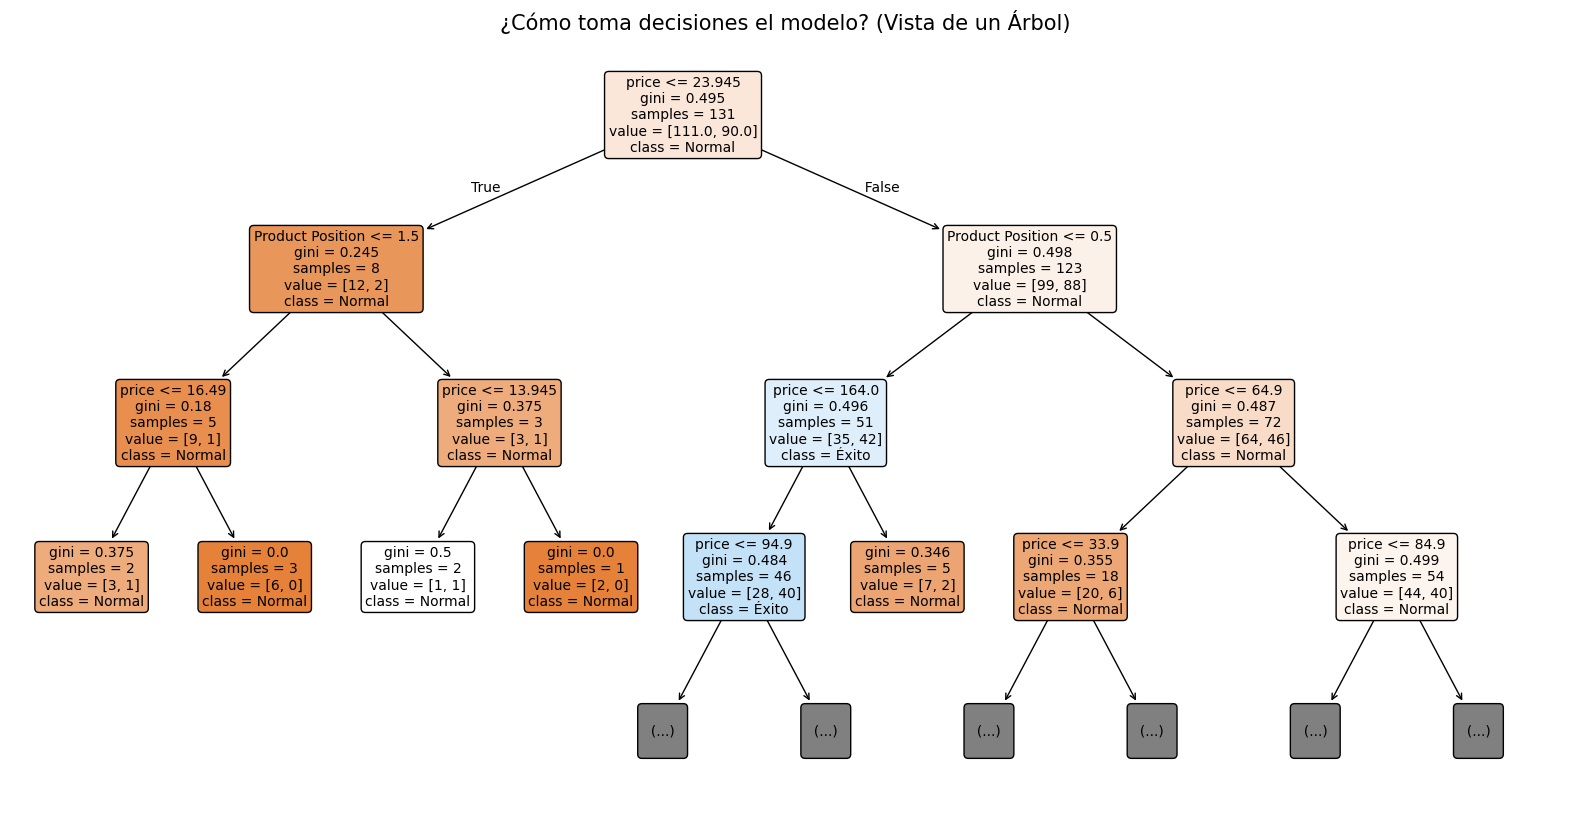

INTERPRETACIÓN:
1. Los cuadros azules indican probabilidad de 'Éxito'.
2. Los cuadros naranjas indican probabilidad de 'Normal'.
3. La primera línea de cada cuadro es la regla (Ej: Price <= 50).


In [2]:
# -------------------------------------------------------
# EXTRA: VISUALIZACIÓN DEL CEREBRO DEL MODELO (Un Árbol)
# -------------------------------------------------------
from sklearn.tree import plot_tree

# Random Forest tiene 100 árboles. Vamos a dibujar solo el primero para entenderlo.
plt.figure(figsize=(20, 10)) # Hacemos el gráfico gigante

plot_tree(rf_model.estimators_[0], 
        feature_names=features,
        class_names=['Normal', 'Éxito'],
        filled=True, 
        rounded=True,
        max_depth=3, # Limitamos la profundidad para que se pueda leer
        fontsize=10)

plt.title('¿Cómo toma decisiones el modelo? (Vista de un Árbol)', fontsize=15)
plt.show()

print("INTERPRETACIÓN:")
print("1. Los cuadros azules indican probabilidad de 'Éxito'.")
print("2. Los cuadros naranjas indican probabilidad de 'Normal'.")
print("3. La primera línea de cada cuadro es la regla (Ej: Price <= 50).")